In [1]:
!pip install "numpy<2.0.0"

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('./anime.csv')

In [3]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
df.shape

(12294, 7)

In [5]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [7]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [8]:
df.drop(columns=['name','anime_id'],inplace=True)

### Fix the genre attribute

In [9]:
# Getting rid of the missing attributes
# df = df.dropna(subset=['genre']).reset_index(drop=True)
df['genre'] = df['genre'].fillna("Unknown")

In [10]:
df.shape

(12294, 5)

In [11]:
df['genre'] = df['genre'].str.split(',')

In [12]:
# df['Adventure']

In [13]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
result = pd.DataFrame(mlb.fit_transform(df['genre']),columns=mlb.classes_)

In [14]:
result['Adventure'].isna().sum()

0

In [15]:
df.index.equals(result.index)

True

In [16]:
df.index.difference(result.index)

RangeIndex(start=0, stop=0, step=1)

In [17]:
df = pd.concat([df, result], axis=1)

In [18]:
df['Adventure'].isna().sum()

0

In [19]:
df.drop(columns='genre',inplace=True)

In [20]:
df.columns

Index(['type', 'episodes', 'rating', 'members', ' Adventure', ' Cars',
       ' Comedy', ' Dementia', ' Demons', ' Drama', ' Ecchi', ' Fantasy',
       ' Game', ' Harem', ' Hentai', ' Historical', ' Horror', ' Josei',
       ' Kids', ' Magic', ' Martial Arts', ' Mecha', ' Military', ' Music',
       ' Mystery', ' Parody', ' Police', ' Psychological', ' Romance',
       ' Samurai', ' School', ' Sci-Fi', ' Seinen', ' Shoujo', ' Shoujo Ai',
       ' Shounen', ' Shounen Ai', ' Slice of Life', ' Space', ' Sports',
       ' Super Power', ' Supernatural', ' Thriller', ' Vampire', ' Yaoi',
       ' Yuri', 'Action', 'Adventure', 'Cars', 'Comedy', 'Dementia', 'Demons',
       'Drama', 'Ecchi', 'Fantasy', 'Game', 'Harem', 'Hentai', 'Historical',
       'Horror', 'Josei', 'Kids', 'Magic', 'Martial Arts', 'Mecha', 'Military',
       'Music', 'Mystery', 'Parody', 'Police', 'Psychological', 'Romance',
       'Samurai', 'School', 'Sci-Fi', 'Seinen', 'Shoujo', 'Shounen',
       'Slice of Life', 'Space'

### Dealing with the feature 'type'

In [21]:
df['type'].nunique()

6

In [22]:
df['type'].value_counts()

TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: type, dtype: int64

In [23]:
df['type'].isnull().sum()

25

In [24]:
# Getting rid of the missing attributes
# df = df.dropna(subset=['type'])

df["type"].fillna(
    df["type"].mode()[0],
    inplace=True
)

In [25]:
df['type'].value_counts()

TV         3812
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: type, dtype: int64

<Axes: >

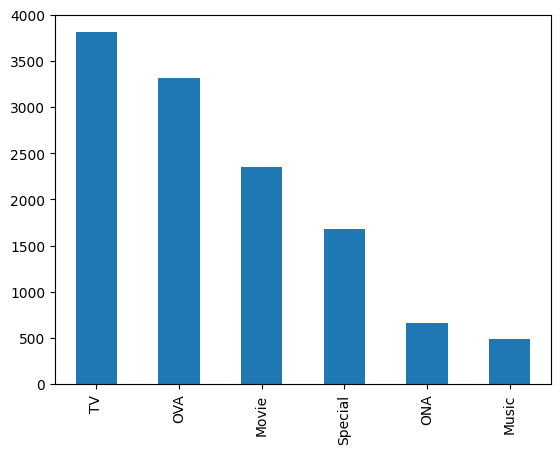

In [26]:
df['type'].value_counts().plot(kind='bar')

In [27]:
df = pd.get_dummies(df,columns=['type'],drop_first=True)

In [28]:
df

,episodes,rating,members,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,...,Supernatural,Thriller,Unknown,Vampire,Yaoi,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,1,9.37,200630,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,64,9.26,793665,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
2,51,9.25,114262,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,24,9.17,673572,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,51,9.16,151266,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12289,1,4.15,211,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
12290,1,4.28,183,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
12291,4,4.88,219,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
12292,1,4.98,175,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## Fixing the Ratings column

#### We can't work on missing ratings

In [29]:
df = df.dropna(subset=['rating'])

In [30]:
df.shape

(12064, 91)

## Fixing Missing Episodes

In [31]:
df["episodes"] = pd.to_numeric(
    df["episodes"],
    errors="coerce"
)

/var/folders/pr/6264cydn30527m2bf6lwj2xr0000gn/T/ipykernel_46684/220109430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["episodes"] = pd.to_numeric(


In [32]:
df["episodes"].fillna(
    df["episodes"].median(),
    inplace=True
)

/var/folders/pr/6264cydn30527m2bf6lwj2xr0000gn/T/ipykernel_46684/4076977429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["episodes"].fillna(


<Axes: xlabel='rating', ylabel='Count'>

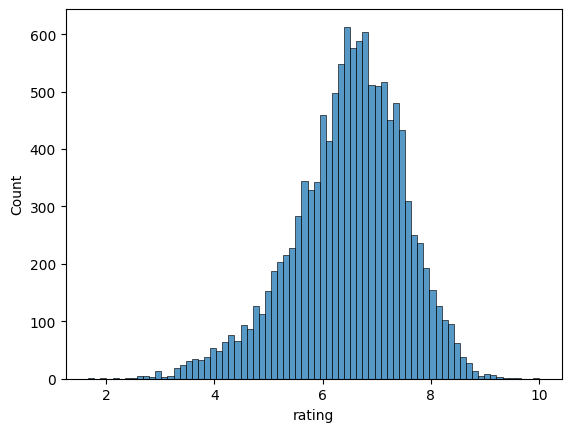

In [33]:
!pip install seaborn

import seaborn as sns

sns.histplot(df['rating'])

In [34]:
df['rating'].skew()

-0.5435700688578504

<Axes: xlabel='episodes', ylabel='rating'>

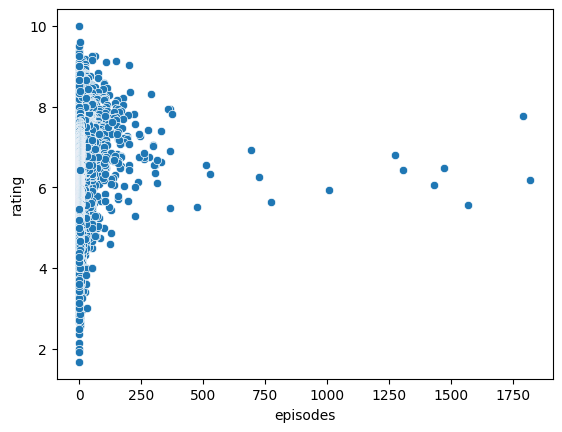

In [35]:
sns.scatterplot(x="episodes",y="rating",data=df)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12064 entries, 0 to 12293
Data columns (total 91 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   episodes        12064 non-null  float64
 1   rating          12064 non-null  float64
 2   members         12064 non-null  int64  
 3    Adventure      12064 non-null  int64  
 4    Cars           12064 non-null  int64  
 5    Comedy         12064 non-null  int64  
 6    Dementia       12064 non-null  int64  
 7    Demons         12064 non-null  int64  
 8    Drama          12064 non-null  int64  
 9    Ecchi          12064 non-null  int64  
 10   Fantasy        12064 non-null  int64  
 11   Game           12064 non-null  int64  
 12   Harem          12064 non-null  int64  
 13   Hentai         12064 non-null  int64  
 14   Historical     12064 non-null  int64  
 15   Horror         12064 non-null  int64  
 16   Josei          12064 non-null  int64  
 17   Kids           12064 non-null 

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler_members = StandardScaler()
df['members'] = scaler_members.fit_transform(df[['members']])

/var/folders/pr/6264cydn30527m2bf6lwj2xr0000gn/T/ipykernel_46684/2624585039.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['members'] = scaler_members.fit_transform(df[['members']])


In [39]:
scaler_episodes = StandardScaler()
df['episodes'] = scaler_episodes.fit_transform(df[['episodes']])

/var/folders/pr/6264cydn30527m2bf6lwj2xr0000gn/T/ipykernel_46684/672939231.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['episodes'] = scaler_episodes.fit_transform(df[['episodes']])


In [40]:
X = df.drop(columns=['rating'])
y = df['rating']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [44]:
!pip install xgboost

In [45]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

xgb.fit(X_train,y_train)

y_pred_xgb = xgb.predict(X_test)

In [46]:
# Replace accuracy with regression metrics
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

# Calculate metrics
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print(f"Root Mean Squared Error: {lr_rmse:.4f}")
print(f"R2 Score: {lr_r2:.4f}")

Root Mean Squared Error: 0.8093
R2 Score: 0.3856


In [49]:
# Replace accuracy with regression metrics
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

# Calculate metrics
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Mean Squared Error: {rf_rmse:.4f}")
print(f"R2 Score: {rf_r2:.4f}")

Mean Squared Error: 0.6526
R2 Score: 0.6004


In [51]:
# Replace accuracy with regression metrics
from sklearn.metrics import root_mean_squared_error, r2_score

# Calculate metrics
xgb_rmse = root_mean_squared_error(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print(f"Mean Squared Error: {xgb_rmse:.4f}")
print(f"R2 Score: {xgb_r2:.4f}")

Mean Squared Error: 0.6431
R2 Score: 0.6120


In [52]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)

[-5.77031179 -6.7371051  -4.56572724 -0.26040836  0.27641916]


In [53]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)

[-7.77531202e+00 -9.50511578e+00 -3.49276512e+00 -5.84191716e-01
  4.06204299e-03]


In [54]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)

[-5.59329759 -5.92051641 -4.04247348 -0.18764206  0.31503187]


In [55]:
from sklearn.model_selection import RandomizedSearchCV

In [56]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators" : [100,200,300,500,700,1000],
    "max_depth": [None, 5 , 10, 15, 20, 30],
    "min_samples_split": [2,5,10,20],
    "min_samples_leaf": [1,2,4,8],
    "max_features": ["sqrt","log2",None],
    "bootstrap": [True,False]
}

In [57]:
rf_random = RandomizedSearchCV(
                estimator=rf,
                param_distributions = param_dist,
                n_iter=50,
                scoring="neg_root_mean_squared_error",
                cv = 5,
                verbose=2,
                random_state=42,
                n_jobs=-1
)

rf_random.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=1000; total time=   8.2s
[CV] END bootstrap=True, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  13.7s
[CV] END bootstrap=True, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=700; total time=   1.6s
[CV] END bootstrap=True, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=700; total time=   1.6s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.8s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=700; total time=   3.7s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimat

/opt/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=500; total time=   2.7s
[CV] END bootstrap=True, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  13.5s
[CV] END bootstrap=False, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   0.6s
[CV] END bootstrap=False, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   0.6s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=   3.8s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=500; total time=   2.3s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time=   0.5s
[CV] END bootstrap=True, max_depth=30, 

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [58]:
print(rf_random.best_params_)

best_rf = rf_random.best_estimator_

y_pred_rf = best_rf.predict(X_test)

{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}


In [59]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

tuned_rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

tuned_rf_r2 = r2_score(
    y_test,
    y_pred_rf
)

print(tuned_rf_rmse)
print(tuned_rf_mae)
print(tuned_rf_r2)

0.6452652708561136
0.4785530496184233
0.6094145005604632


In [60]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_dist = {

    "n_estimators": [
        100,
        200,
        300,
        500,
        700,
        1000
    ],

    "max_depth": [
        3,
        4,
        5,
        6,
        8,
        10
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "subsample": [
        0.6,
        0.8,
        1.0
    ],

    "colsample_bytree": [
        0.6,
        0.8,
        1.0
    ],

    "min_child_weight": [
        1,
        3,
        5,
        7
    ],

    "gamma": [
        0,
        0.1,
        0.3,
        0.5,
        1
    ]
}

In [61]:
xgb_random = RandomizedSearchCV(
    estimator=xgb,

    param_distributions=param_dist,

    n_iter=50,

    cv=5,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    verbose=2,

    n_jobs=-1
)

In [62]:
xgb_random.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"XGBRegressor(...state=42, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [63]:
print(
    xgb_random.best_params_
)

{'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [64]:
best_xgb = xgb_random.best_estimator_

y_pred = best_xgb.predict(X_test)

tuned_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

tuned_xgb_mae = mean_absolute_error(
    y_test,
    y_pred
)

tuned_xgb_r2 = r2_score(
    y_test,
    y_pred
)

print(tuned_xgb_rmse)
print(tuned_xgb_mae)
print(tuned_xgb_r2)

0.6363198345336935
0.46993287211772666
0.6201689581987332


In [65]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Random Forest Tuned",
        "XGBoost",
        "XGBoost Tuned"
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        tuned_rf_rmse,
        xgb_rmse,
        tuned_xgb_rmse
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        tuned_rf_mae,
        xgb_mae,
        tuned_xgb_mae
    ],
    "R2": [
        lr_r2,
        rf_r2,
        tuned_rf_r2,
        xgb_r2,
        tuned_xgb_r2
    ]
})

results.sort_values(
    by="RMSE"
)

,Model,RMSE,MAE,R2
4,XGBoost Tuned,0.636320,0.469933,0.620169
3,XGBoost,0.643131,0.474262,0.611994
2,Random Forest Tuned,0.645265,0.478553,0.609415
1,Random Forest,0.652631,0.476522,0.600446
0,Linear Regression,0.809263,0.624786,0.385646


[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=1000; total time=   8.4s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=20, n_estimators=200; total time=   0.9s
[CV] END bootstrap=False, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   1.3s
[CV] END bootstrap=False, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   1.2s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time=   3.4s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time=   3.7s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=   3.8s
[CV] END bootstrap=True, max_dept

[CV] END bootstrap=False, max_depth=15, max_features=None, min_samples_leaf=4, min_samples_split=20, n_estimators=100; total time=   6.2s
[CV] END bootstrap=True, max_depth=20, max_features=None, min_samples_leaf=8, min_samples_split=2, n_estimators=1000; total time=  33.4s
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=1000; total time=   7.9s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   5.3s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   6.1s
[CV] END bootstrap=True, max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=700; total time=   8.9s
[CV] END bootstrap=False, max_depth=20, max_features=sqrt, min_samples_leaf=8, min_samples_split=5, n_estimators=200; total time=   1.6s
[CV] END bootstrap=False, max_depth=No

[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=1000; total time=   8.3s
[CV] END bootstrap=True, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  13.6s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=500; total time=   2.3s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time=   0.6s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.8s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.7s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=700; total time=   3.7s
[CV] END bootstrap=True, max_dept

[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=1000; total time=   7.2s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   5.2s
[CV] END bootstrap=True, max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=700; total time=   8.2s
[CV] END bootstrap=True, max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=700; total time=   7.9s
[CV] END bootstrap=False, max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time=   0.7s
[CV] END bootstrap=False, max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time=   0.7s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END bootstrap=False, max_depth=30,

[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=1000; total time=   8.2s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=20, n_estimators=200; total time=   0.9s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=20, n_estimators=200; total time=   0.9s
[CV] END bootstrap=False, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   1.2s
[CV] END bootstrap=False, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   1.2s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time=   3.4s
[CV] END bootstrap=False, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END bootstrap=False, max_depth=